# 📊 Sentiment Analysis on Twitter Airline Data

## 🎯 Objective
The objective of this project is to analyze tweets and classify them into **positive, negative, and neutral sentiments** using NLP techniques. This helps in understanding public opinion and trends.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob

## 📁 Dataset Information

- Dataset: Twitter US Airline Sentiment
- Contains tweets about airlines
- Important columns:
  - text (tweet content)
  - airline
  - airline_sentiment (actual sentiment)

In [ ]:
df = pd.read_csv("/content/Tweets.csv")
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 🔍 Data Understanding

- Dataset contains text data (tweets)
- Sentiments are already labeled
- We will compare predicted sentiment with actual sentiment

In [ ]:
df.info()
df['airline_sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


## 🧠 Sentiment Analysis

We use **TextBlob** to calculate sentiment polarity:
- Positive → polarity > 0
- Neutral → polarity = 0
- Negative → polarity < 0

In [ ]:
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity == 0:
        return 'neutral'
    else:
        return 'negative'

In [ ]:
df['predicted_sentiment'] = df['text'].apply(get_sentiment)
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,predicted_sentiment
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),neutral
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),neutral
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),negative
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),positive
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),negative


## 📊 Data Visualization

Visualizing sentiment distribution helps understand public opinion.

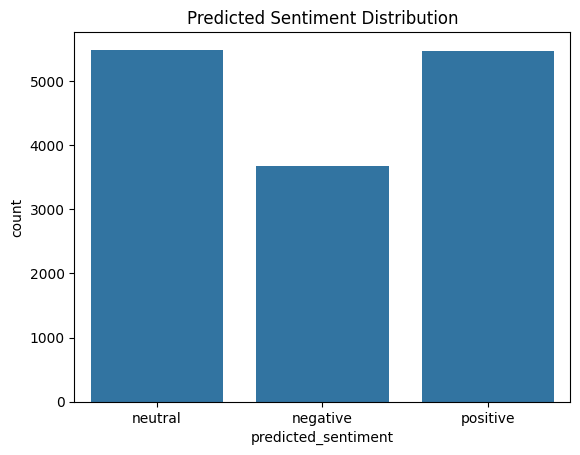

In [ ]:
sns.countplot(x='predicted_sentiment', data=df)
plt.title("Predicted Sentiment Distribution")
plt.show()

### 🔄 Sentiment Comparison by Airline

This graph shows how different airlines are perceived based on predicted sentiment.

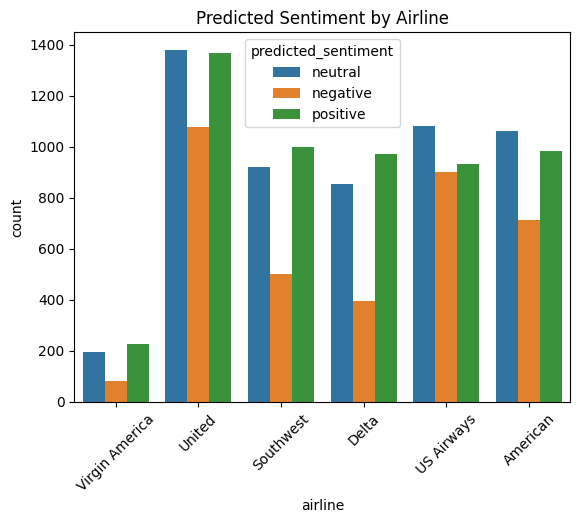

In [ ]:
sns.countplot(x='airline', hue='predicted_sentiment', data=df)
plt.title("Predicted Sentiment by Airline")
plt.xticks(rotation=45)
plt.show()

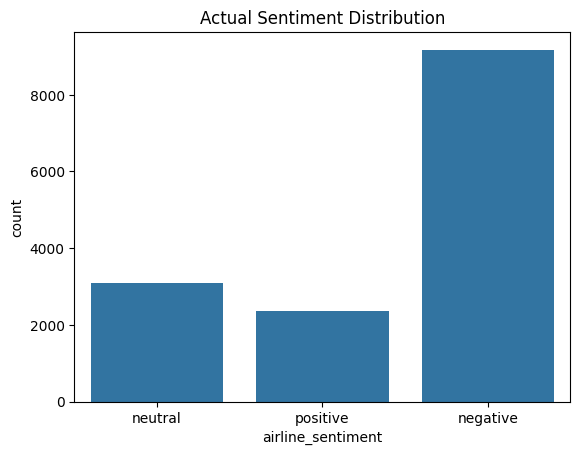

In [ ]:
sns.countplot(x='airline_sentiment', data=df)
plt.title("Actual Sentiment Distribution")
plt.show()

## 📏 Model Evaluation

We compare predicted sentiment with actual sentiment to check accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df['airline_sentiment'], df['predicted_sentiment'])
print("Model Accuracy:", accuracy)

Model Accuracy: 0.4644125683060109


## 🔍 Insights

- Most tweets are **negative**, indicating customer dissatisfaction
- Some airlines receive more negative feedback
- Positive sentiments are fewer
- Neutral sentiments represent balanced opinions

## ⚠️ Limitations

- TextBlob is a basic NLP tool
- Cannot detect sarcasm
- Limited accuracy compared to advanced models

## ✅ Conclusion

This project successfully performs sentiment analysis on airline tweets.

- Majority of tweets are negative
- Sentiment analysis helps understand customer opinions
- Useful for improving services and decision-making

Overall, this project shows how NLP can extract insights from text data.